## 1. DATASET

### Đường dẫn file

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.datasets import make_moons
from sklearn.neighbors import KDTree
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# --- 1.1. TẠO DỮ LIỆU HÌNH TRĂNG KHUYẾT ---
def generate_optimized_data(n_samples=15000):
    X, _ = make_moons(n_samples=n_samples, noise=0.08, random_state=42)
    df = pd.DataFrame(X, columns=['x', 'y'])
    return df

print("Đang tạo bộ dữ liệu 15,000 dòng dạng phi tuyến tính...")
df = generate_optimized_data(15000)
print(df.head())

Đang tạo bộ dữ liệu 15,000 dòng dạng phi tuyến tính...
          x         y
0  1.087118 -0.403070
1 -0.897376  0.472950
2  1.802167 -0.163275
3  0.857879  0.245095
4 -0.789864  0.583937


In [7]:
df.to_csv('/content/drive/MyDrive/HKD_2026/ML/CuoiKy/data_moons.csv', index=False)
print("Đã lưu dữ liệu vào file 'data_moons.csv' thành công!")
print(df.head())

Đã lưu dữ liệu vào file 'data_moons.csv' thành công!
          x         y
0  1.087118 -0.403070
1 -0.897376  0.472950
2  1.802167 -0.163275
3  0.857879  0.245095
4 -0.789864  0.583937


### 1.1. Tiền xử lý dữ liệu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang đọc dữ liệu từ: /content/drive/MyDrive/HKD_2026/ML/CuoiKy/data_moons.csv
Đã lưu file sạch tại: preprocessed.csv


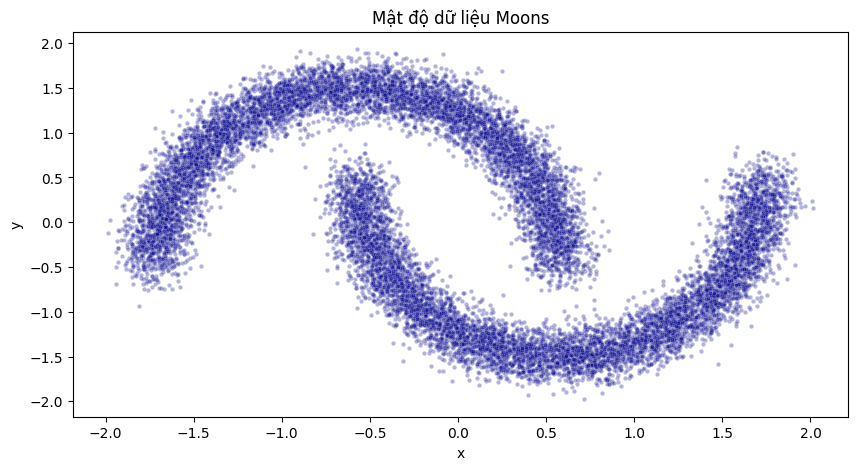

In [8]:
# 1. Kết nối với Google Drive (Nếu bạn chưa mount trước đó)
drive.mount('/content/drive')

# 2. Đường dẫn file bạn đã lưu ở bước trước
FILE_PATH = '/content/drive/MyDrive/HKD_2026/ML/CuoiKy/data_moons.csv'

# 3. Đọc dữ liệu từ file CSV trên Drive
print(f"Đang đọc dữ liệu từ: {FILE_PATH}")
df = pd.read_csv(FILE_PATH)

# --- 4. TIỀN XỬ LÝ ---
features = ['x', 'y']
X_raw = df[features].copy()
X_raw = X_raw.fillna(X_raw.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

df_final = pd.DataFrame(X_scaled, columns=features)

FILE_OUT_CSV = 'preprocessed.csv'
df_final.to_csv(FILE_OUT_CSV, index=False)
print(f"Đã lưu file sạch tại: {FILE_OUT_CSV}")

# Trực quan hóa ban đầu
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_final, x='x', y='y', alpha=0.3, color='darkblue', s=10)
plt.title('Mật độ dữ liệu Moons')
plt.show()

In [9]:
PATH_DIR = ""

## 2. DBSCAN

DBSCAN Silhouette Score: 0.3159


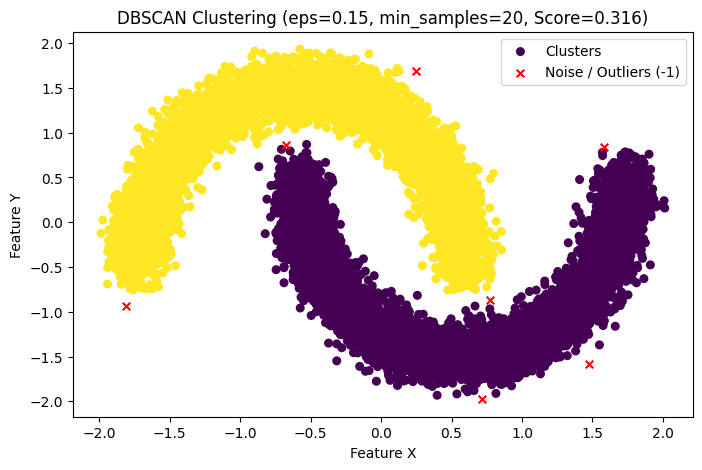

In [10]:
# 2 DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Lấy dữ liệu đã tiền xử lý
X_db_coords = df_final[['x', 'y']].values

# Cấu hình DBSCAN
# Ở đây dùng eps=0.15, min_samples=20 để đồng bộ với phần Incremental DBSCAN ở dưới
dbscan = DBSCAN(eps=0.15, min_samples=20)
df_final['DBSCAN_Labels'] = dbscan.fit_predict(X_db_coords)

# Đánh giá (Silhouette score chỉ tính được khi số lượng cụm sinh ra > 1 và không tính toàn bộ là nhiễu)
unique_labels = set(df_final['DBSCAN_Labels'])
if len(unique_labels) > 1 and len(unique_labels) < len(X_db_coords):
    score_dbscan = silhouette_score(X_db_coords, df_final['DBSCAN_Labels'])
    print(f"DBSCAN Silhouette Score: {score_dbscan:.4f}")
else:
    score_dbscan = 0
    print("DBSCAN: Không thể tính Silhouette Score (chỉ có 1 cụm hoặc tất cả dữ liệu bị coi là nhiễu).")

# Trực quan trên x, y
plt.figure(figsize=(8, 5))

# Tách riêng các điểm nhiễu (label = -1) và các điểm thuộc cụm để vẽ cho rõ
outliers = df_final[df_final['DBSCAN_Labels'] == -1]
clusters = df_final[df_final['DBSCAN_Labels'] != -1]

# Vẽ các cụm
plt.scatter(clusters['x'], clusters['y'], c=clusters['DBSCAN_Labels'], cmap='viridis', s=30, label='Clusters')
# Vẽ các điểm nhiễu (outliers)
plt.scatter(outliers['x'], outliers['y'], c='red', marker='x', s=30, label='Noise / Outliers (-1)')

plt.title(f'DBSCAN Clustering (eps=0.15, min_samples=20, Score={score_dbscan:.3f})')
plt.xlabel('Feature X')
plt.ylabel('Feature Y')
plt.legend()
plt.show()
# Lưu file kết quả riêng
df_final[['x', 'y', 'DBSCAN_Labels'] + features].to_excel(PATH_DIR + 'Result_DBSCAN.xlsx', index=False)

## 3. INCREMENTAL DBSCAN

Đang chạy Incremental DBSCAN (Strong Merge)...
Đang chạy Traditional DBSCAN (Retrain All)...

====================== BẢNG SO SÁNH CHI TIẾT ======================
            Algorithm  Total Time (s)  Silhouette ↑  Davies-Bouldin ↓  \
0  Traditional DBSCAN         20.1074        0.3159            3.8400   
1  Incremental DBSCAN          3.3413        0.3398            2.7485   

   Clusters  
0         2  
1         2  


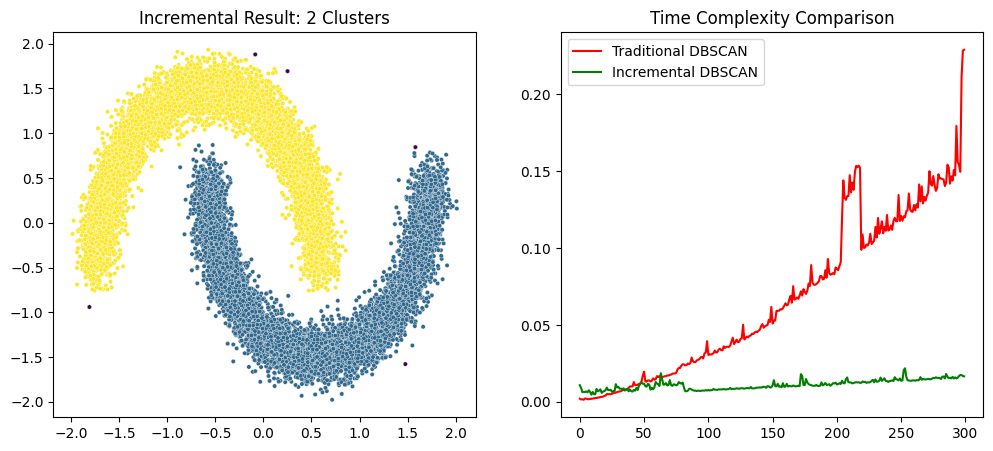


====== HỆ THỐNG ĐANG LƯU KẾT QUẢ INCREMENTAL DBSCAN ======
Thành công! Đã lưu file tại: Result_Incremental_DBSCAN.xlsx


In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import KDTree
from sklearn.cluster import DBSCAN

# =========================
# CẤU HÌNH THAM SỐ
# =========================
EPS_PARAM = 0.15
MIN_SAMPLES_PARAM = 20
BATCH_SIZE = 50
PATH_DIR = ""

# Lấy tọa độ và danh sách tính năng
X_coords = df_final[['x', 'y']].values
features = ['x', 'y']

# =========================
# INCREMENTAL DBSCAN
# =========================
class IncrementalDBSCAN:
    def __init__(self, eps=0.15, min_samples=20):
        self.eps = eps
        self.min_samples = min_samples
        self.data = []
        self.labels = []
        self.cluster_id = 0
        self.tree = None

    def build_tree(self):
        if len(self.data) > 0:
            self.tree = KDTree(np.array(self.data))

    def region_query(self, point_idx):
        return self.tree.query_radius([self.data[point_idx]], r=self.eps)[0]

    def expand_cluster(self, start_idx, neighbors, target_id):
        old_label = self.labels[start_idx]
        if old_label > 0 and old_label != target_id:
            self.labels = [target_id if l == old_label else l for l in self.labels]

        self.labels[start_idx] = target_id
        queue = set(neighbors)

        while len(queue) > 0:
            current_idx = queue.pop()
            current_label = self.labels[current_idx]

            if current_label > 0 and current_label != target_id:
                self.labels = [target_id if l == current_label else l for l in self.labels]

            if self.labels[current_idx] <= 0:
                is_unvisited = (self.labels[current_idx] == -99)
                self.labels[current_idx] = target_id

                if is_unvisited:
                    new_neighbors = self.region_query(current_idx)
                    if len(new_neighbors) >= self.min_samples:
                        for n in new_neighbors:
                            queue.add(n)

    def partial_fit(self, X_batch):
        start_idx = len(self.data)
        for point in X_batch:
            self.data.append(point)
            self.labels.append(-99)

        self.build_tree()

        for i in range(start_idx, len(self.data)):
            if self.labels[i] != -99:
                continue

            neighbors = self.region_query(i)

            if len(neighbors) < self.min_samples:
                for n_idx in neighbors:
                    if self.labels[n_idx] > 0:
                        self.labels[i] = self.labels[n_idx]
                        break
                if self.labels[i] == -99:
                    self.labels[i] = -1
            else:
                existing_ids = list(set([self.labels[n] for n in neighbors if self.labels[n] > 0]))
                if existing_ids:
                    self.expand_cluster(i, neighbors, existing_ids[0])
                else:
                    self.cluster_id += 1
                    self.expand_cluster(i, neighbors, self.cluster_id)

    def get_labels(self):
        return np.array(self.labels)

# =========================
# CHẠY THUẬT TOÁN & SO SÁNH
# =========================
print("Đang chạy Incremental DBSCAN (Strong Merge)...")
inc_model = IncrementalDBSCAN(eps=EPS_PARAM, min_samples=MIN_SAMPLES_PARAM)
inc_batch_times = []

for i in range(0, len(X_coords), BATCH_SIZE):
    batch = X_coords[i : i + BATCH_SIZE]
    start = time.time()
    inc_model.partial_fit(batch)
    inc_batch_times.append(time.time() - start)

labels_inc = inc_model.get_labels()
total_time_inc = sum(inc_batch_times)

# Gán nhãn vào DataFrame chính
df_final['INC_DBSCAN_Labels'] = labels_inc

# Traditional DBSCAN
X_accumulate = []
db_batch_times = []
print("Đang chạy Traditional DBSCAN (Retrain All)...")
for i in range(0, len(X_coords), BATCH_SIZE):
    batch = X_coords[i : i + BATCH_SIZE]
    X_accumulate.extend(batch)
    start = time.time()
    DBSCAN(eps=EPS_PARAM, min_samples=MIN_SAMPLES_PARAM).fit(X_accumulate)
    db_batch_times.append(time.time() - start)

total_time_db = sum(db_batch_times)
labels_db = DBSCAN(eps=EPS_PARAM, min_samples=MIN_SAMPLES_PARAM).fit_predict(X_coords)

# =========================
# TÍNH TOÁN METRICS & DASHBOARD
# =========================
def get_metrics(X, labels):
    n = len(set(labels)) - (1 if -1 in labels else 0)
    if n > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels), n
    return -1, -1, n

sil_inc, dbi_inc, n_inc = get_metrics(X_coords, labels_inc)
sil_db, dbi_db, n_db = get_metrics(X_coords, labels_db)

print("\n====================== BẢNG SO SÁNH CHI TIẾT ======================")
df_compare = pd.DataFrame({
    "Algorithm": ["Traditional DBSCAN", "Incremental DBSCAN"],
    "Total Time (s)": [total_time_db, total_time_inc],
    "Silhouette ↑": [sil_db, sil_inc],
    "Davies-Bouldin ↓": [dbi_db, dbi_inc],
    "Clusters": [n_db, n_inc]
}).round(4)
print(df_compare)

# Trực quan hóa
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_coords[:,0], y=X_coords[:,1], hue=labels_inc, palette='viridis', s=10, legend=None)
plt.title(f"Incremental Result: {n_inc} Clusters")

plt.subplot(1, 2, 2)
plt.plot(db_batch_times, label='Traditional DBSCAN', color='red')
plt.plot(inc_batch_times, label='Incremental DBSCAN', color='green')
plt.legend()
plt.title("Time Complexity Comparison")
plt.show()

# =========================
# LƯU KẾT QUẢ RA FILE EXCEL
# =========================
print("\n====== HỆ THỐNG ĐANG LƯU KẾT QUẢ INCREMENTAL DBSCAN ======")
try:
    file_output = PATH_DIR + 'Result_Incremental_DBSCAN.xlsx'
    df_final[['x', 'y', 'INC_DBSCAN_Labels'] + features].to_excel(file_output, index=False)
    print(f"Thành công! Đã lưu file tại: {file_output}")
except Exception as e:
    print(f"Lỗi khi lưu file: {e}")

## 4. K-MEANS

K-Means Silhouette Score: 0.4950


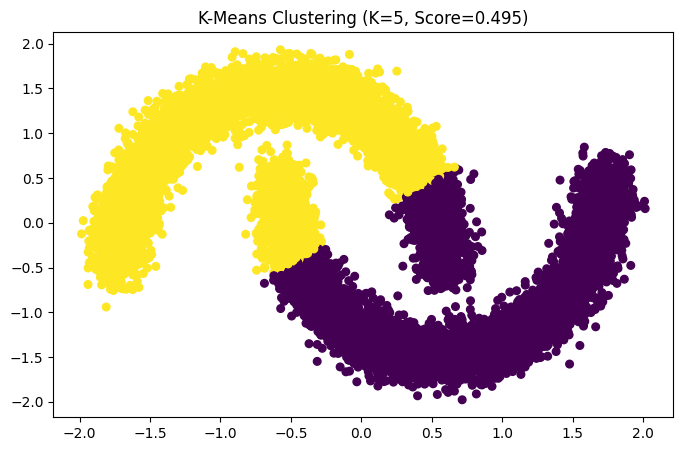

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Lấy dữ liệu đã tiền xử lý
X = df_final[['x', 'y']].values

# Chạy K-Means với cấu hình tối ưu
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=20, random_state=42)
df_final['KMeans_Labels'] = kmeans.fit_predict(X)

# Đánh giá
score_km = silhouette_score(X, df_final['KMeans_Labels'])
print(f"K-Means Silhouette Score: {score_km:.4f}")

# Trực quan trên x, y
plt.figure(figsize=(8, 5))
plt.scatter(df_final['x'], df_final['y'], c=df_final['KMeans_Labels'], cmap='viridis', s=30)
plt.title(f'K-Means Clustering (K=5, Score={score_km:.3f})')
plt.show()

# Lưu file kết quả riêng
df_final[['x', 'y', 'KMeans_Labels'] + features].to_excel(PATH_DIR + 'Result_KMeans.xlsx', index=False)

## 5. HAC

HAC Silhouette Score: 0.4521


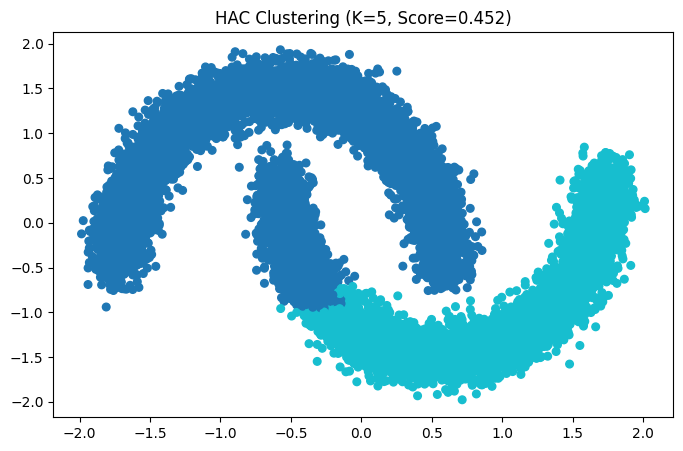

In [13]:
from sklearn.cluster import AgglomerativeClustering

# Chạy HAC với linkage 'ward'
hac = AgglomerativeClustering(n_clusters=2, linkage='ward')
df_final['HAC_Labels'] = hac.fit_predict(X)

# Đánh giá
score_hac = silhouette_score(X, df_final['HAC_Labels'])
print(f"HAC Silhouette Score: {score_hac:.4f}")

# Trực quan trên x, y
plt.figure(figsize=(8, 5))
plt.scatter(df_final['x'], df_final['y'], c=df_final['HAC_Labels'], cmap='tab10', s=30)
plt.title(f'HAC Clustering (K=5, Score={score_hac:.3f})')
plt.show()

# Lưu file kết quả riêng
df_final[['x', 'y', 'HAC_Labels'] + features].to_excel(PATH_DIR + 'Result_HAC.xlsx', index=False)

## 6. ĐÁNH GIÁ KẾT QUẢ CÁC THUẬT TOÁN

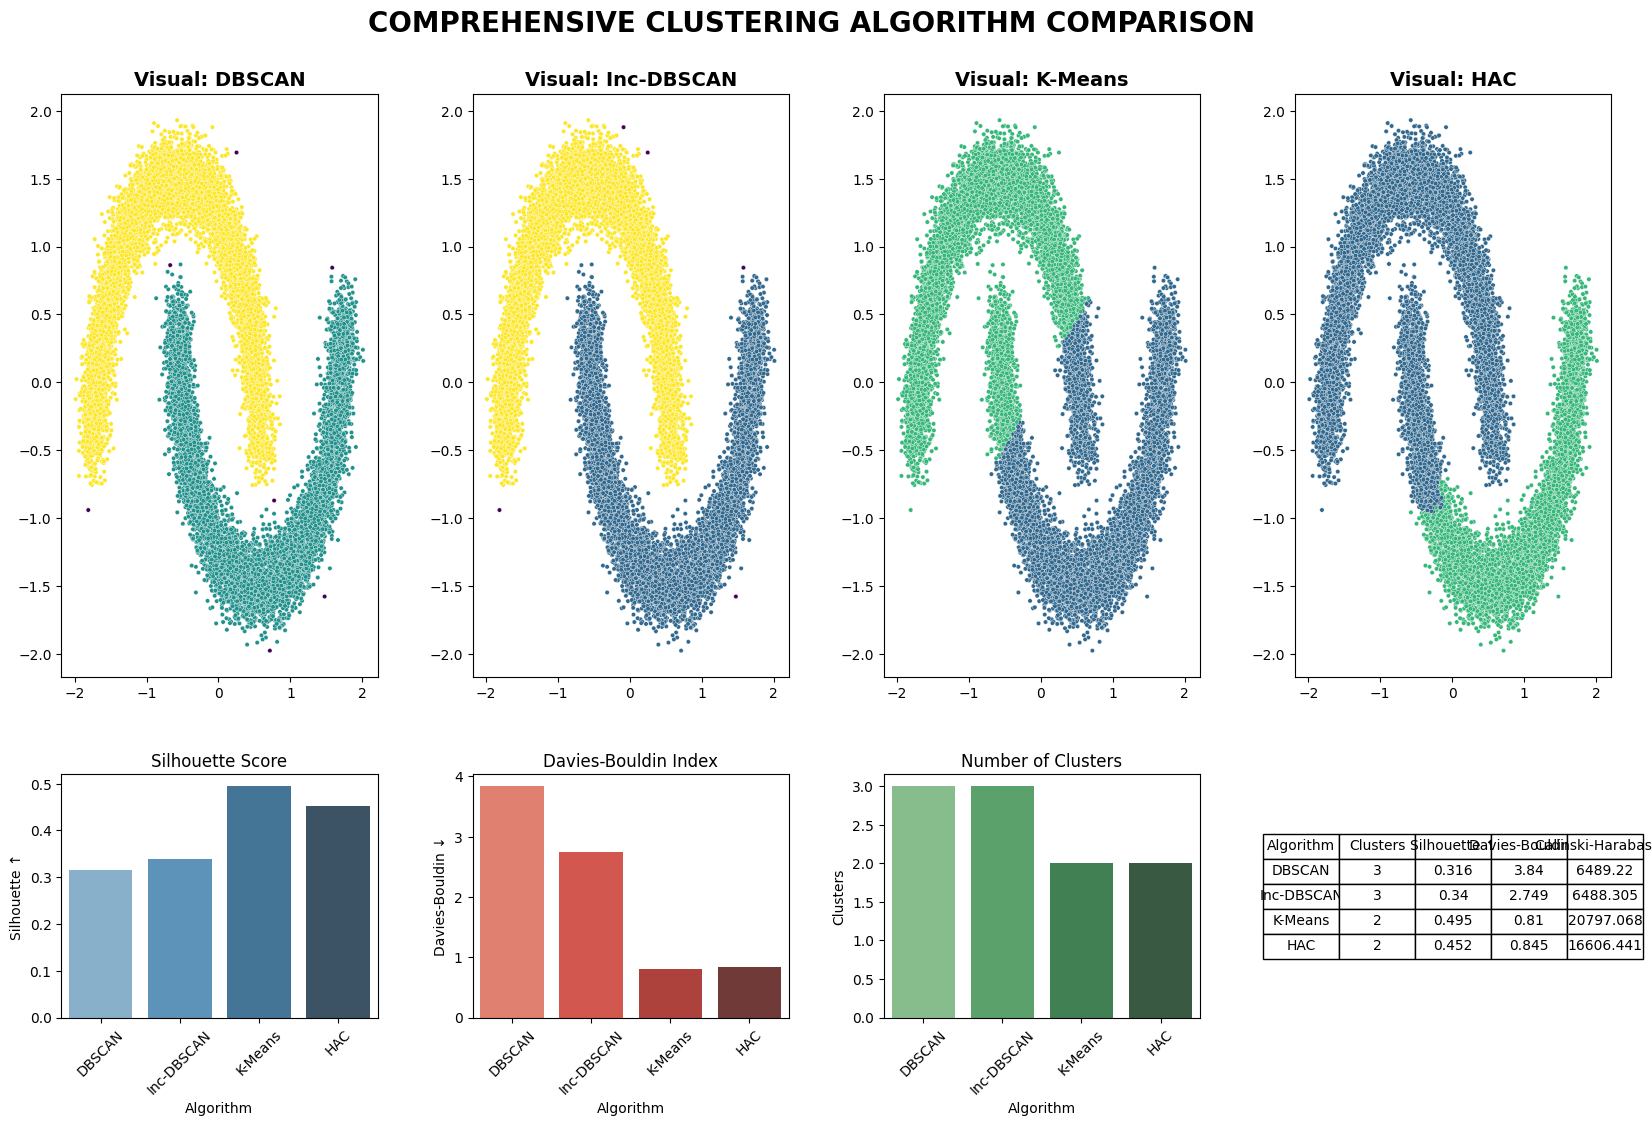


================= BẢNG SO SÁNH CHI TIẾT =================
 Algorithm  Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
    DBSCAN         3      0.315943          3.840028          6489.219755
Inc-DBSCAN         3      0.339759          2.748544          6488.304930
   K-Means         2      0.494966          0.809675         20797.067736
       HAC         2      0.452094          0.845090         16606.441070


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ========================================================
# 1. TỔNG HỢP DỮ LIỆU ĐÁNH GIÁ
# ========================================================
results = []

def collect_metrics(algo_name, labels, X):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        chs = calinski_harabasz_score(X, labels)
    else:
        sil, dbi, chs = 0, 0, 0

    return {
        "Algorithm": algo_name,
        "Clusters": n_clusters,
        "Silhouette ↑": sil,
        "Davies-Bouldin ↓": dbi,
        "Calinski-Harabasz ↑": chs
    }

# Thu thập dữ liệu từ các cột nhãn đã tạo trong df_final
X_eval = df_final[['x', 'y']].values

algos = {
    "DBSCAN": df_final['DBSCAN_Labels'],
    "Inc-DBSCAN": df_final['INC_DBSCAN_Labels'],
    "K-Means": df_final['KMeans_Labels'],
    "HAC": df_final['HAC_Labels']
}

for name, labels in algos.items():
    results.append(collect_metrics(name, labels, X_eval))

df_metrics = pd.DataFrame(results)

# ========================================================
# 2. TRỰC QUAN HÓA SO SÁNH (VISUALIZATION)
# ========================================================
fig = plt.figure(figsize=(20, 12))
grid = plt.GridSpec(3, 4, wspace=0.3, hspace=0.4)

# --- Phân đoạn 1: Biểu đồ phân cụm của từng thuật toán ---
for i, (name, labels) in enumerate(algos.items()):
    ax = fig.add_subplot(grid[0:2, i])
    sns.scatterplot(x=df_final['x'], y=df_final['y'], hue=labels,
                    palette='viridis', s=10, ax=ax, legend=None)
    ax.set_title(f"Visual: {name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")

# --- Phân đoạn 2: So sánh Silhouette Score ---
ax_sil = fig.add_subplot(grid[2, 0])
sns.barplot(data=df_metrics, x='Algorithm', y='Silhouette ↑',
            hue='Algorithm', palette='Blues_d', ax=ax_sil, legend=False)
ax_sil.set_title("Silhouette Score", fontsize=12)
ax_sil.tick_params(axis='x', rotation=45)

# --- Phân đoạn 3: So sánh Davies-Bouldin ---
ax_dbi = fig.add_subplot(grid[2, 1])
sns.barplot(data=df_metrics, x='Algorithm', y='Davies-Bouldin ↓',
            hue='Algorithm', palette='Reds_d', ax=ax_dbi, legend=False)
ax_dbi.set_title("Davies-Bouldin Index", fontsize=12)
ax_dbi.tick_params(axis='x', rotation=45)

# --- Phân đoạn 4: Số lượng cụm tìm thấy ---
ax_n = fig.add_subplot(grid[2, 2])
sns.barplot(data=df_metrics, x='Algorithm', y='Clusters',
            hue='Algorithm', palette='Greens_d', ax=ax_n, legend=False)
ax_n.set_title("Number of Clusters", fontsize=12)
ax_n.tick_params(axis='x', rotation=45)

# --- Phân đoạn 5: Bảng dữ liệu chi tiết ---
ax_table = fig.add_subplot(grid[2, 3])
ax_table.axis('tight')
ax_table.axis('off')
table = ax_table.table(cellText=df_metrics.round(3).values,
                       colLabels=df_metrics.columns,
                       cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.suptitle("COMPREHENSIVE CLUSTERING ALGORITHM COMPARISON", fontsize=20, fontweight='bold', y=0.95)
plt.show()

# In bảng kết quả ra console
print("\n================= BẢNG SO SÁNH CHI TIẾT =================")
print(df_metrics.to_string(index=False))